# GradCAM from Captum Library implementation

In [8]:
import numpy as np
from torchvision.models import resnet
import torchvision.transforms as transforms
from torchvision import datasets

import torch
from captum.attr import GuidedGradCam, IntegratedGradients, InputXGradient

import kagglehub
import os

from utils.plot import plot_random_six_images, plot_idx_labeled, plot_with_function
from utils.model_eval import test_on_given_idx

#SEEDS
np.random.seed(7)
torch.manual_seed(7)


## Data

In [9]:
# Download latest version
DATA_PATH = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
IMG_PATH = os.path.join(DATA_PATH, "images", "Images")
ANNOTATION_PATH = os.path.join(DATA_PATH, "annotations", "Annotations")

print("Path to dataset files:", DATA_PATH)

dataset = datasets.ImageFolder(root=IMG_PATH)

Path to dataset files: /home/franio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2


### Transform, set and Loader
Normalization is done with standard image net $\mu$ and $\sigma$

In [10]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Compose([transforms.Resize((224,224)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean, std)])

# Images and Predictions

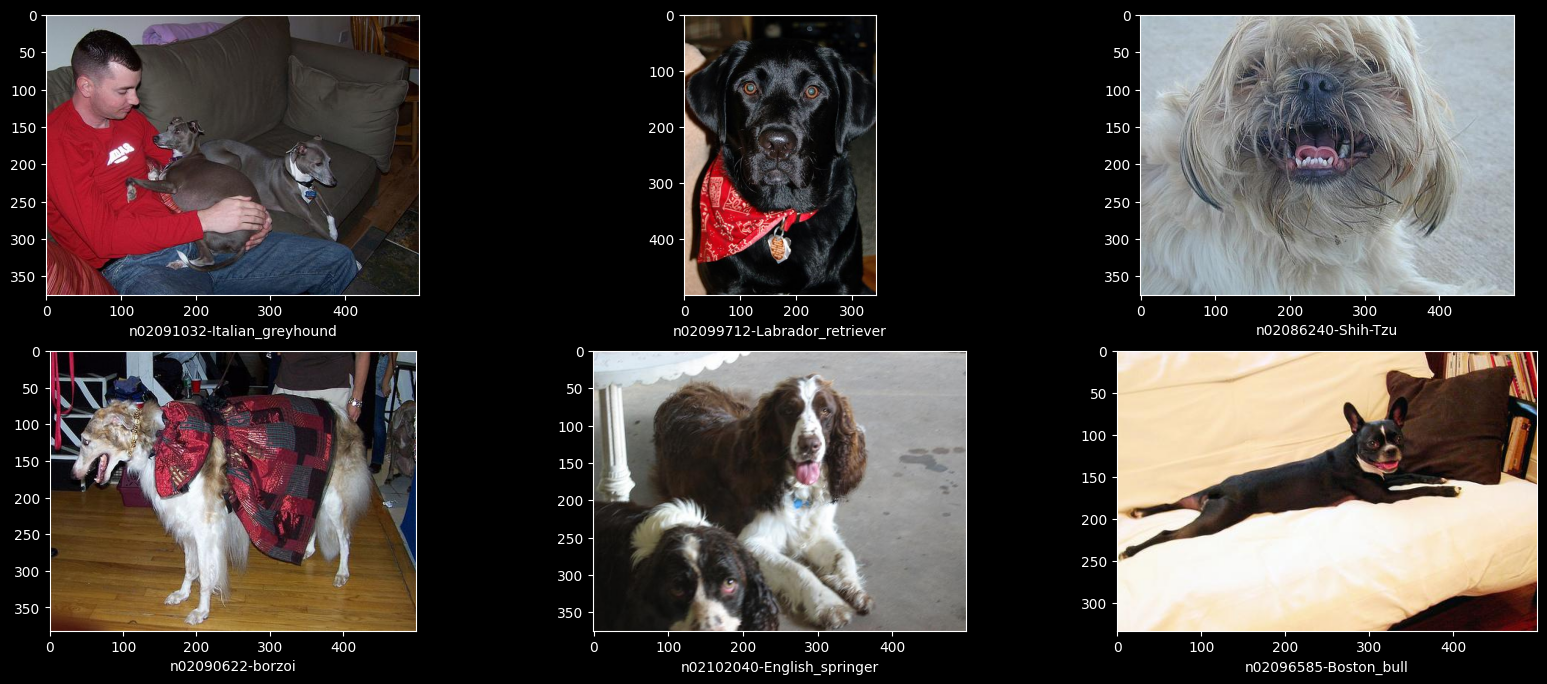

In [11]:
idx = plot_random_six_images(dataset, dataset.classes)

## Loding Model and Prediction

In [12]:
MODEL_NAME = 'resnet18_dogs_5_epochs'

net_model = resnet.resnet18()
net_model.load_state_dict(torch.load(os.path.join('models', f"{MODEL_NAME}.pth"), weights_only=True))

preds, df = test_on_given_idx(dataset, net_model,transform, idx=idx)

df

,Idx,True_Label,Predicted_Label
0,3658,n02091032-Italian_greyhound,n02091032-Italian_greyhound
1,10311,n02099712-Labrador_retriever,n02099712-Labrador_retriever
2,929,n02086240-Shih-Tzu,n02086240-Shih-Tzu
3,3370,n02090622-borzoi,n02090622-borzoi
4,11629,n02102040-English_springer,n02102040-English_springer
5,8139,n02096585-Boston_bull,n02087046-toy_terrier


array([ 3658, 10311,   929,  3370, 11629,  8139])

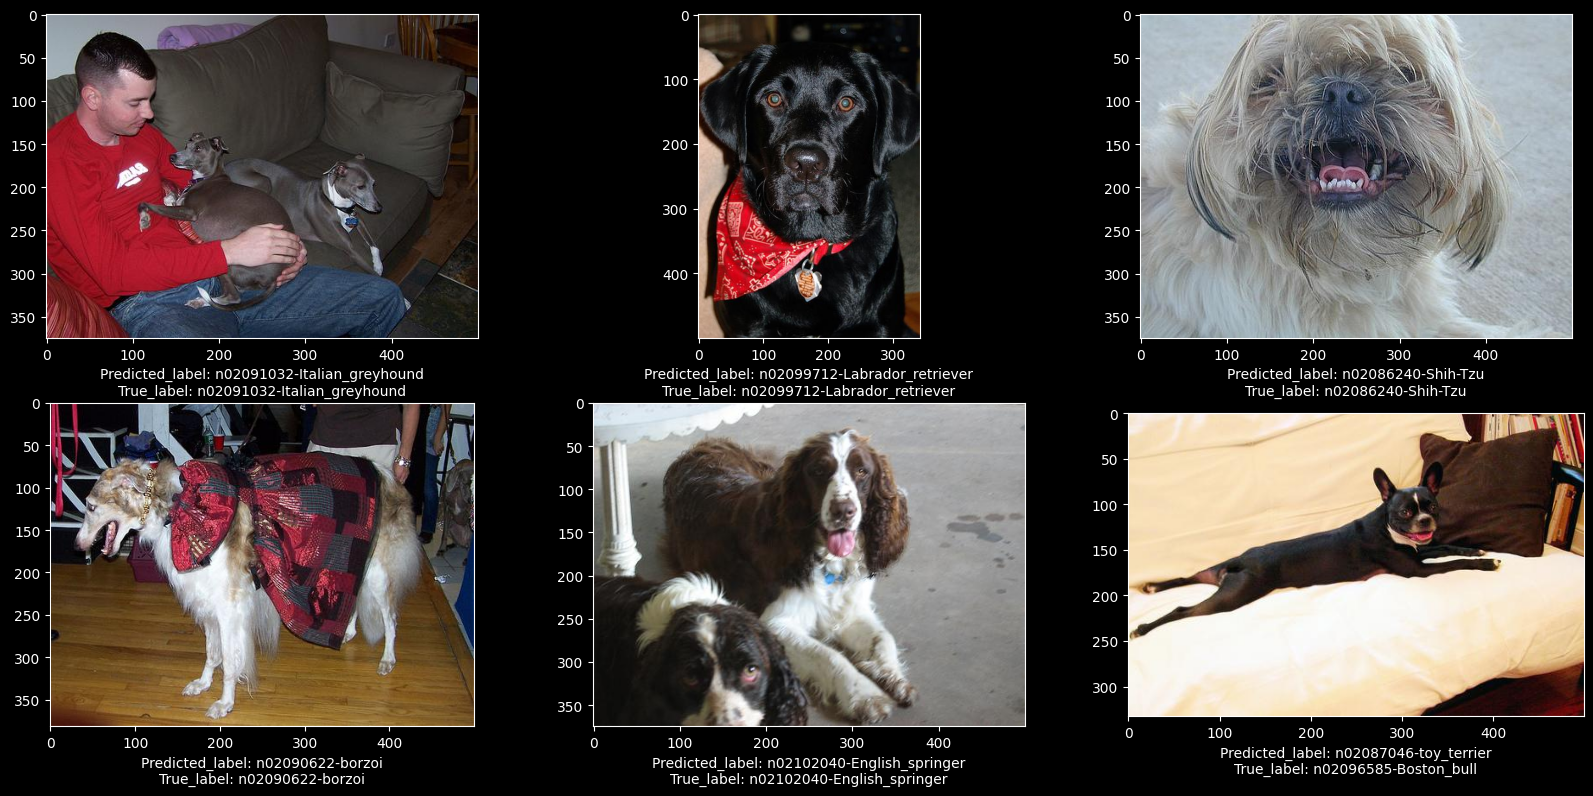

In [13]:
plot_idx_labeled(idx,preds,dataset)

# Guided GradCAM
Guided GradCAM is a combination of GradCAM methods with guided Backpropagation.

## Layer4
The fine tuned one

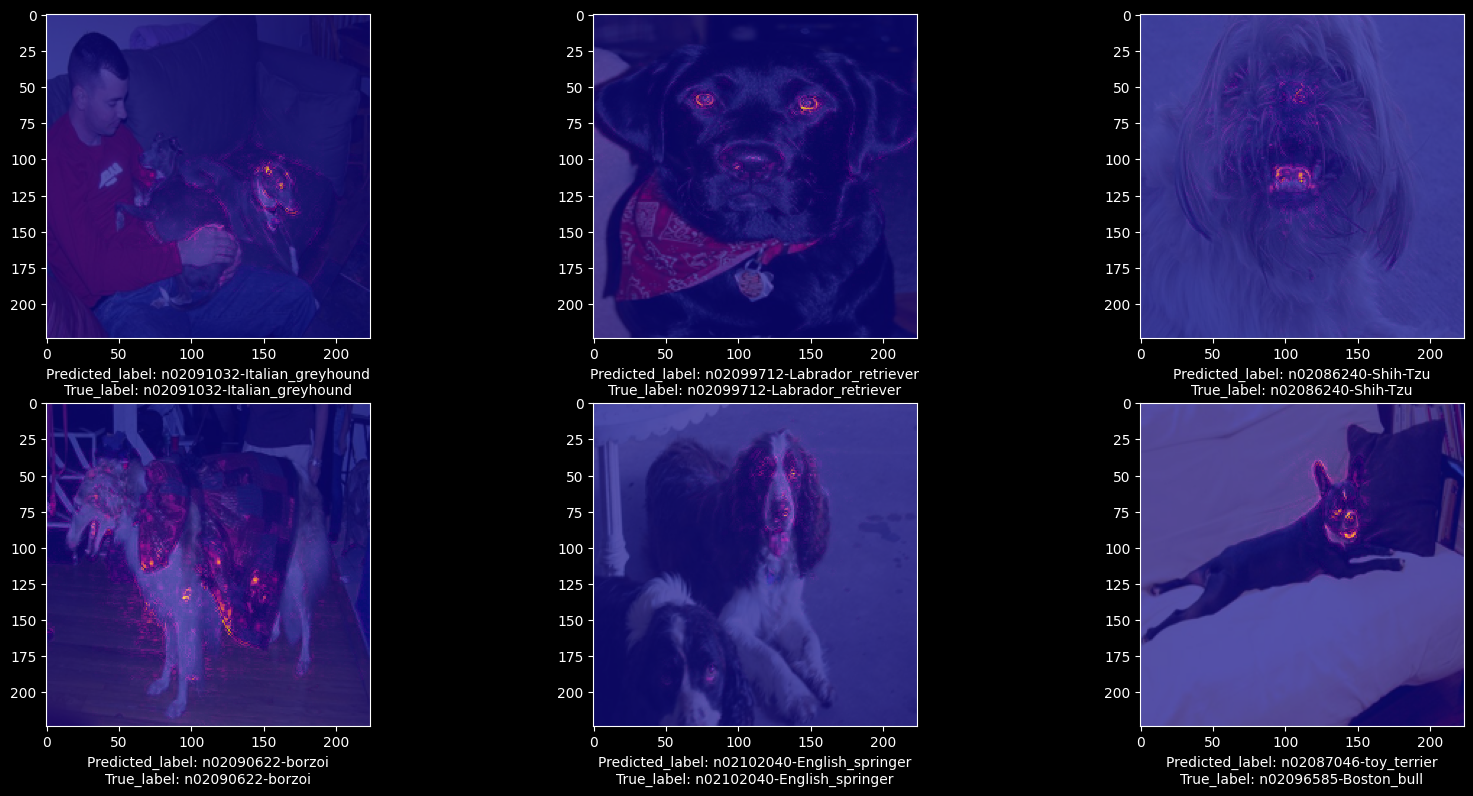

In [14]:
guided_gc = GuidedGradCam(net_model.cpu(), net_model.layer4)
plot_with_function(idx, preds, dataset, guided_gc.attribute, transform=transform)

## Layer 1
As the first feature extraction

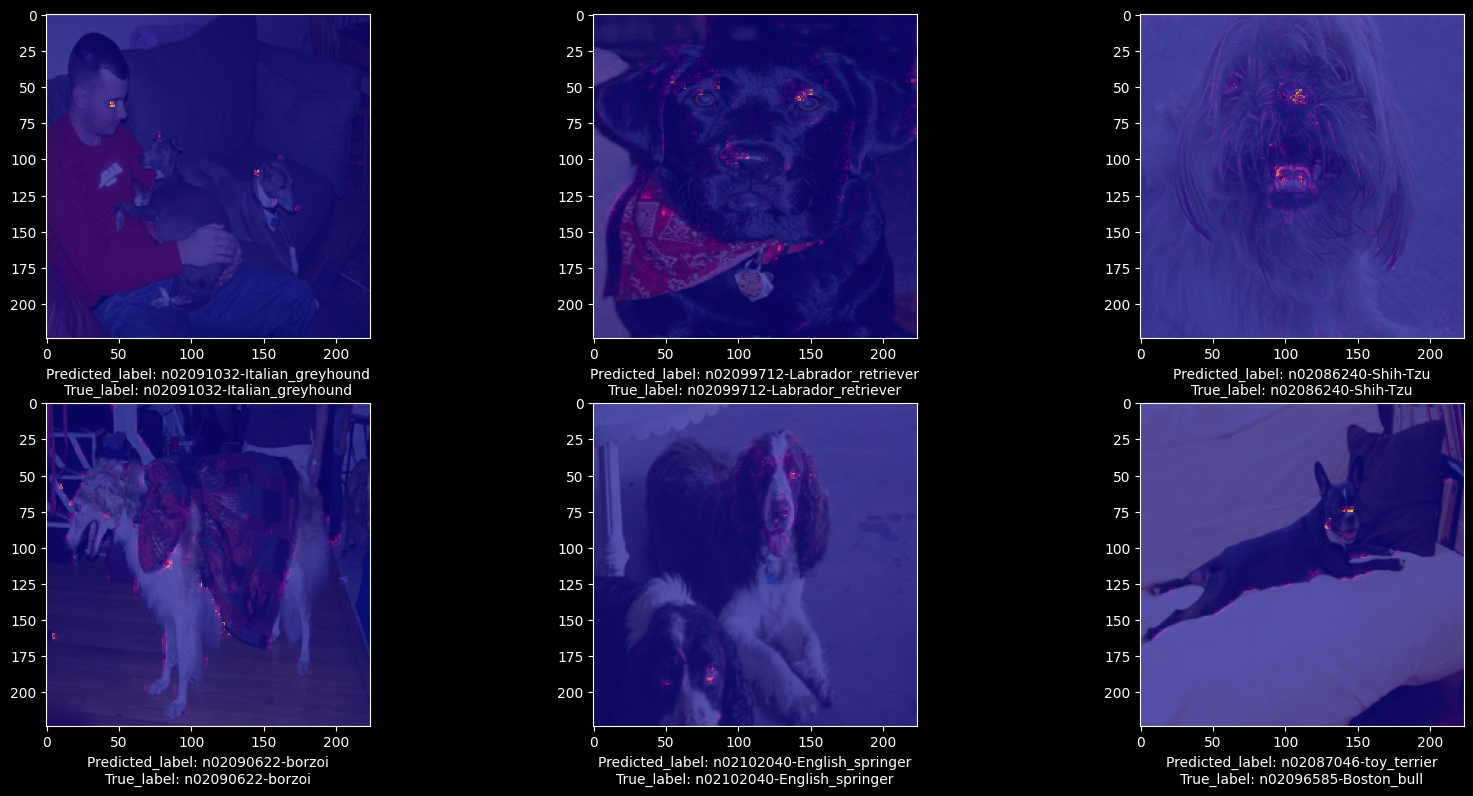

In [15]:
guided_gc1 = GuidedGradCam(net_model.cpu(), net_model.layer1)
plot_with_function(idx, preds, dataset, guided_gc1.attribute, transform=transform)

# Intagrated Gradients


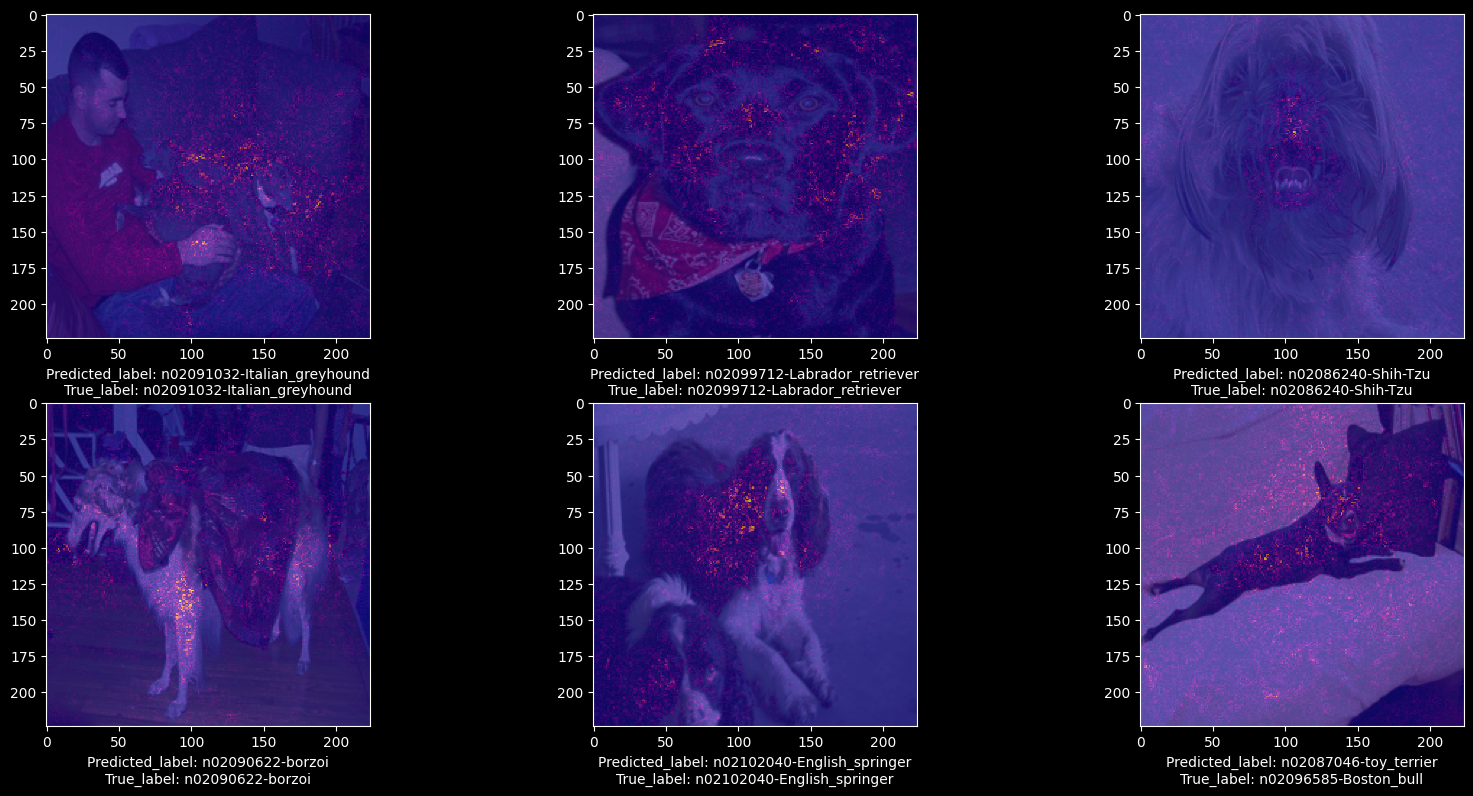

In [16]:
ic = IntegratedGradients(net_model.cpu())
plot_with_function(idx, preds, dataset, ic.attribute, transform=transform)

# Input X Gradient

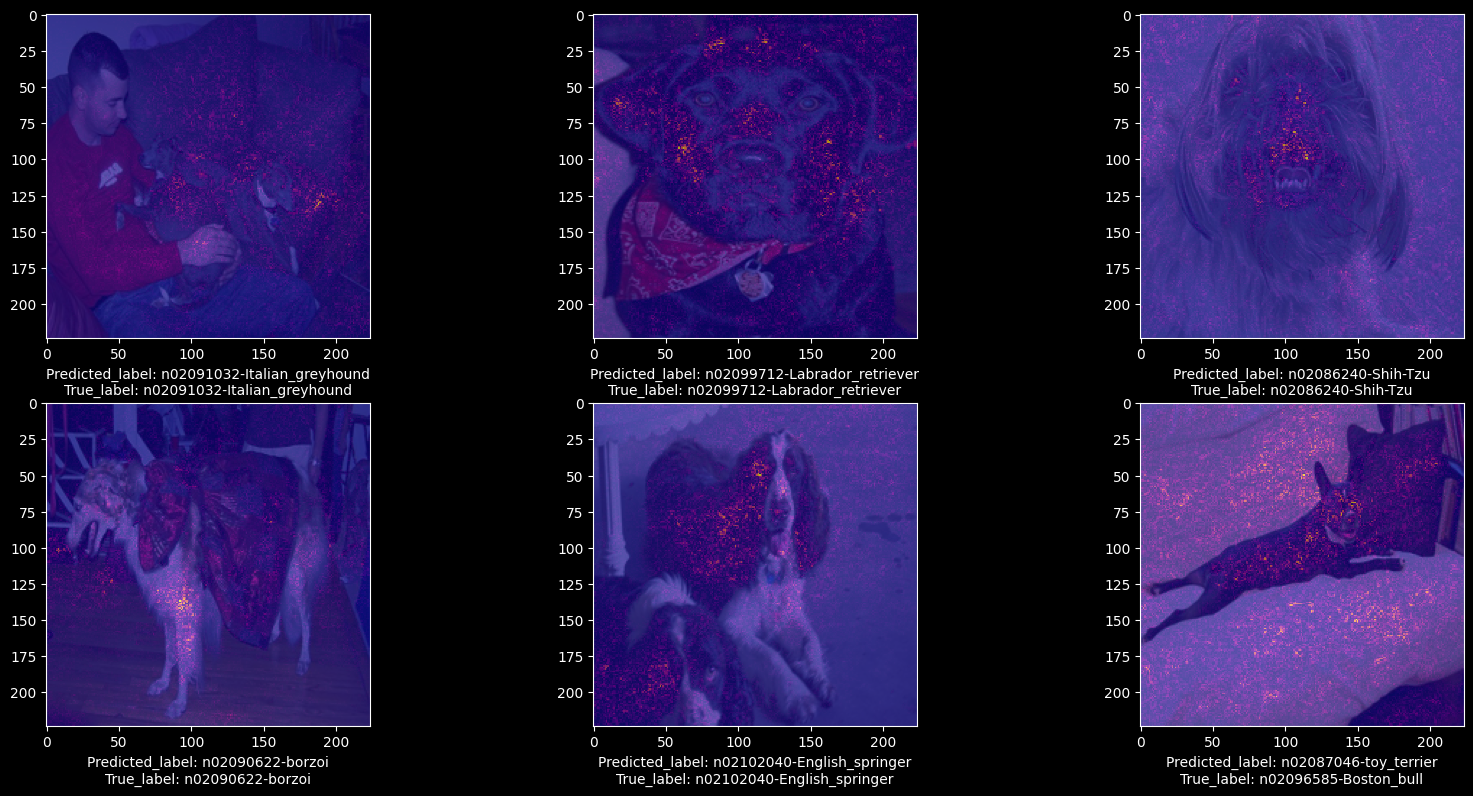

In [17]:
ixg = InputXGradient(net_model)
plot_with_function(idx, preds, dataset, ixg.attribute, transform=transform)